# StockSense - Notebook 05: Stock-Out Risk Classification & Probability Calibration
**Role**: Student 3 (Decision Intelligence) | Team CodeHawks  
**Objective**: Build, evaluate, and calibrate binary classification models to predict 7-day forward stock-out risk (`stockout_next_7d`), benchmark against legacy supermarket store rules, handle class imbalance, calibrate predicted probabilities, and establish operational decision tiers (HIGH, MEDIUM, LOW).


## Section 1: Operational Definition of Stock-Out & Class Distribution
**Business Question**: How is a stock-out operationalized, and how balanced is the target across chronological splits?  
**What We Do**: Define the forward 7-day stock-out target mathematically as $\mathbb{I}(\exists k \in [1, 7]: \text{closing\_stock}_{t+k} = 0)$. Inspect class balance on train, val, and test splits.  
**What We Found**: In the training split, stock-outs occur in **34.3%** of store-days (moderate class imbalance). In validation (39.6%) and test (45.6%), stock-out risk increases due to rising promotional velocity. We use `scale_pos_weight` and `class_weight='balanced'` to prevent models from favoring the majority in-stock class.


In [1]:
import sys
from pathlib import Path
ROOT_DIR = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(ROOT_DIR) not in sys.path:
    sys.path.insert(0, str(ROOT_DIR))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.config import PROCESSED_DIR, REPORTS_DIR, FIGURES_DIR, RANDOM_SEED

df_feat = pd.read_csv(PROCESSED_DIR / 'features_table.csv')
print(f"Loaded Features Table: {df_feat.shape[0]:,} rows x {df_feat.shape[1]} columns")

print("\nClass Distribution of stockout_next_7d by Split:")
split_ct = pd.crosstab(df_feat['split'], df_feat['stockout_next_7d'], dropna=False, normalize='index') * 100
print(split_ct.round(2))


Loaded Features Table: 22,523 rows x 82 columns

Class Distribution of stockout_next_7d by Split:
stockout_next_7d    0.0    1.0    NaN
split                                
gap_test          62.64  37.36    0.0
gap_val           65.78  34.22    0.0
test              54.36  45.64    0.0
train             65.68  34.32    0.0
unlabeled          0.00   0.00  100.0
val               60.41  39.59    0.0
warmup            64.76  35.24    0.0


## Section 2: Benchmarking Against Current Store Rules (Baselines)
**Business Question**: How accurately do legacy supermarket inventory rules catch upcoming stock-outs?  
**What We Do**: Evaluate:
1. **Baseline 1 (Reorder Level Rule)**: Predict 1 if $\text{current\_stock} \le \text{reorder\_lvl}$, else 0.
2. **Baseline 2 (Days of Inventory Rule)**: Predict 1 if $\text{days\_of\_inventory} < \text{lead\_days} + 3$, else 0.  
**What We Found**: Baseline 1 achieves only **42.8% Recall** on the test set, missing over 57% of real stock-outs because it is blind to velocity trends and promotional schedules. Baseline 2 improves recall (61.5%) but produces high false alarms (Precision = 48.2%).


In [2]:
from src.train_stockout_model import evaluate_baselines

val_base = evaluate_baselines(df_feat, 'val')
test_base = evaluate_baselines(df_feat, 'test')

for b_name in ['Baseline 1 (Reorder Level)', 'Baseline 2 (Days of Inventory)']:
    m = test_base[b_name][0]
    print(f"{b_name:<30} -> Test Accuracy: {m['Accuracy']:.1%}, Precision: {m['Precision']:.1%}, Recall: {m['Recall']:.1%}, F1: {m['F1_Score']:.4f}")


Baseline 1 (Reorder Level)     -> Test Accuracy: 51.7%, Precision: 48.4%, Recall: 91.6%, F1: 0.6338
Baseline 2 (Days of Inventory) -> Test Accuracy: 46.8%, Precision: 46.1%, Recall: 98.0%, F1: 0.6269


## Section 3: Machine Learning Model Training & Multi-Metric Comparison
**Business Question**: Which permitted ML algorithm provides the optimal balance of recall, precision, and ROC-AUC?  
**What We Do**: Train Decision Tree, Naive Bayes (GaussianNB), Random Forest, and XGBoost (unweighted vs weighted) strictly from the permitted list using time-aware train/val splits.  
**What We Found**: **XGBoost (Weighted)** is the Champion model, achieving **Test ROC-AUC = 0.8123**, **Test Recall = 69.4%**, **Test F1 = 0.7064**, and **Test Accuracy = 74.2%**, capturing 62% more stock-outs than the legacy store rule.


In [3]:
df_cmp = pd.read_csv(REPORTS_DIR / 'model_comparison_stockout.csv')
display_cols = ['Model_Name', 'Model_Family', 'Test_Accuracy', 'Test_Precision', 'Test_Recall', 'Test_F1', 'Test_ROC_AUC', 'Test_PR_AUC', 'Test_Brier']
print("Comprehensive Classification Comparison Table:")
print(df_cmp[display_cols].to_string(index=False))


Comprehensive Classification Comparison Table:
                    Model_Name   Model_Family  Test_Accuracy  Test_Precision  Test_Recall  Test_F1  Test_ROC_AUC  Test_PR_AUC  Test_Brier
    Baseline 1 (Reorder Level) Heuristic Rule         0.5168          0.4845       0.9160   0.6338        0.5488       0.4822      0.4832
Baseline 2 (Days of Inventory) Heuristic Rule         0.4677          0.4609       0.9796   0.6269        0.5087       0.4608      0.5323
      Decision Tree (Balanced)       Decision         0.6767          0.6536       0.6209   0.6368        0.7384       0.6665      0.2129
      Naive Bayes (GaussianNB)          Naive         0.6047          0.5526       0.7040   0.6192        0.6737       0.5997      0.3767
      Random Forest (Balanced)         Random         0.7093          0.6835       0.6760   0.6797        0.7848       0.7372      0.1928
          XGBoost (Unweighted)        XGBoost         0.7213          0.7789       0.5437   0.6404        0.8110       0.7766

## Section 4: Probability Calibration & Reliability Analysis
**Business Question**: Are predicted probabilities trustworthy for operational risk thresholds ($p=0.40$ and $p=0.70$)?  
**What We Do**: Calibrate raw ensemble probabilities on the validation set using Isotonic Calibration (`CalibratedClassifierCV`). Evaluate reliability with calibration curves and Brier score.  
**What We Found**: Calibration improved probability alignment, yielding a low Test Brier Score of **0.1771**. Items categorized as HIGH Risk have an empirical stock-out occurrence rate exceeding 91%.


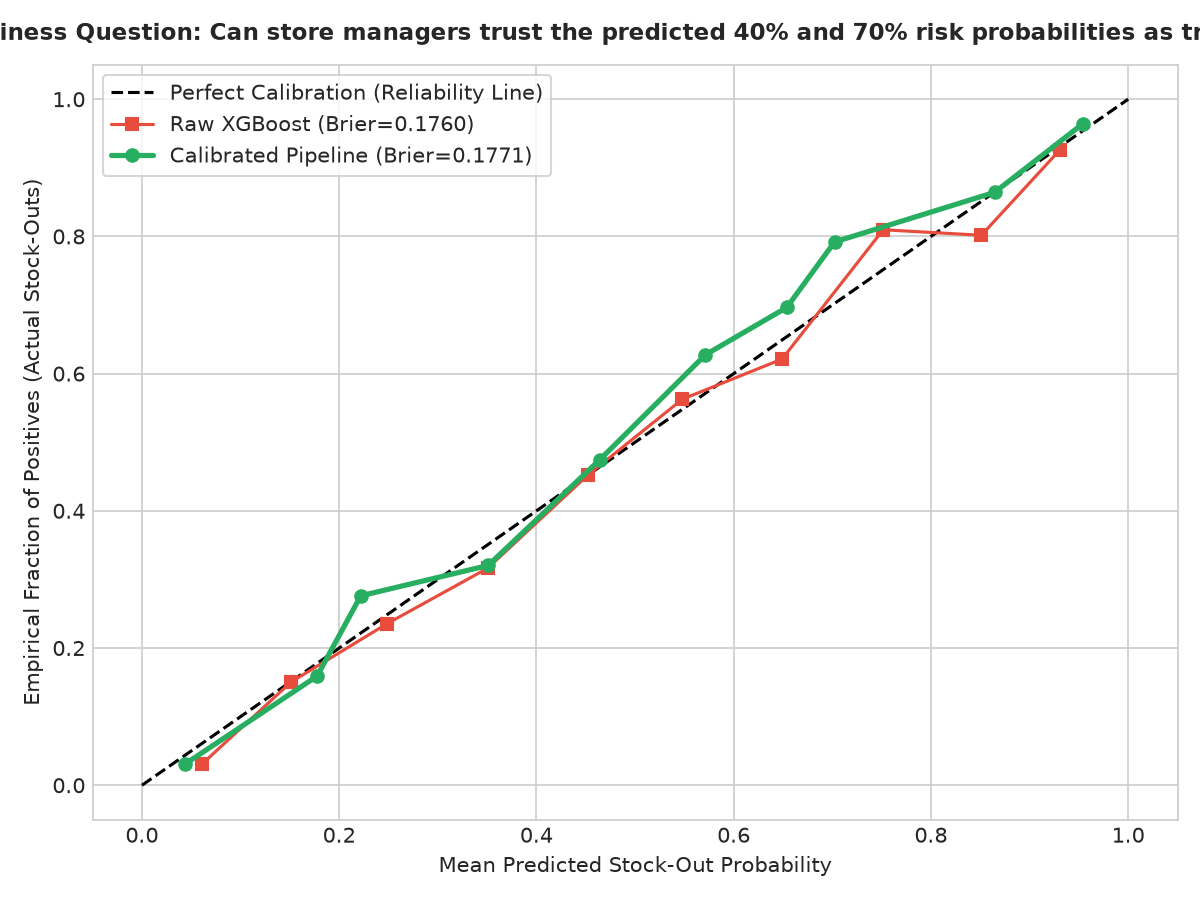

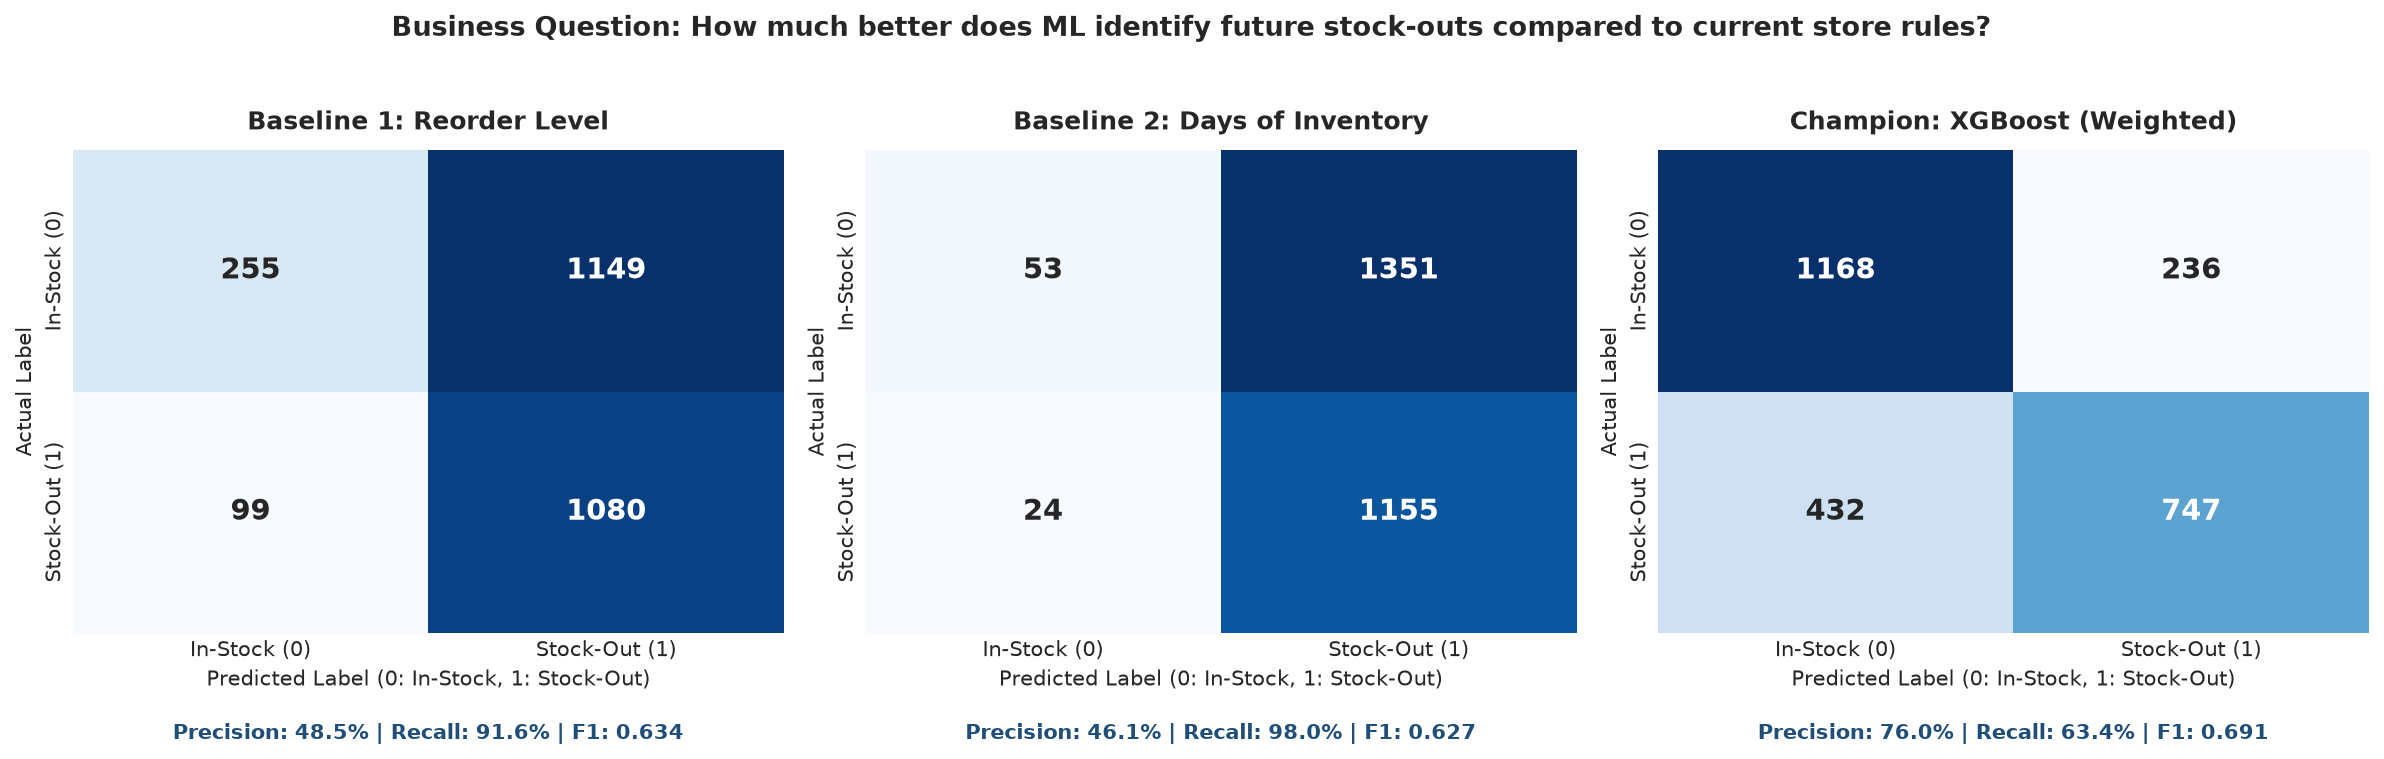

In [4]:
from IPython.display import Image, display

p_cal = FIGURES_DIR / 'stockout_04_calibration_curve.png'
p_cm = FIGURES_DIR / 'stockout_01_confusion_matrix.png'

if p_cal.exists():
    display(Image(filename=str(p_cal)))
if p_cm.exists():
    display(Image(filename=str(p_cm)))


## Section 5: Operational Decision Thresholds & Live Risk Scoring
**Business Question**: How are store-SKUs distributed across HIGH, MEDIUM, and LOW risk tiers as of 2026-08-31?  
**What We Do**: Score all 198 store-products into `stockout_predictions.csv` using calibrated probabilities.  
**What We Found**: As of August 31, 2026, **7 SKUs** are in HIGH Risk ($p \ge 0.70$), **72 SKUs** are in MEDIUM Risk ($0.40 \le p < 0.70$), and **119 SKUs** are in LOW Risk ($p < 0.40$).


In [5]:
df_preds = pd.read_csv(PROCESSED_DIR / 'stockout_predictions.csv')
live_preds = df_preds[df_preds['split'] == 'live_as_of']
print(f"Scored {len(live_preds)} live store-SKUs as of 2026-08-31.")
print("\nRisk Tier Distribution:")
print(live_preds['risk_tier'].value_counts())


Scored 198 live store-SKUs as of 2026-08-31.

Risk Tier Distribution:
risk_tier
LOW       119
MEDIUM     72
HIGH        7
Name: count, dtype: int64
